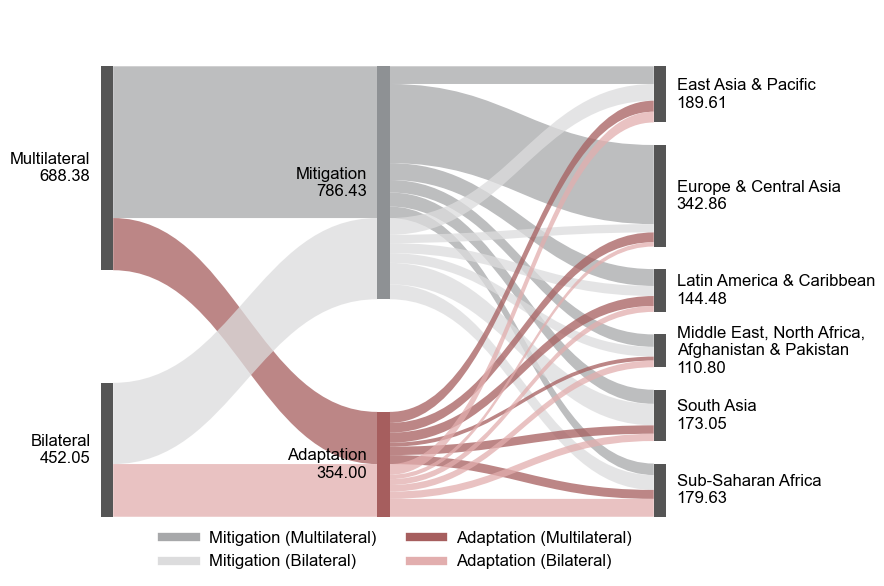

In [21]:
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch, Rectangle
import pandas as pd

# =========================
# 1. Data
# =========================
data = pd.DataFrame({
    "region": [
        "East Asia & Pacific",
        "Europe & Central Asia",
        "Latin America & Caribbean",
        "Middle East, North Africa,\nAfghanistan & Pakistan",
        "South Asia",
        "Sub-Saharan Africa"
    ],
    "Multilateral_Mitigation": [59.71345964, 267.138621, 56.99619718, 42.05927909, 47.60898968, 38.75135932],
    "Bilateral_Mitigation": [56.49873753, 28.0019398, 33.9176767, 32.96371072, 72.53798372, 50.23804224],
    "Bilateral_Adaptation": [36.25132589, 14.58510737, 19.82248041, 22.39721997, 24.49554115, 60.33975783],
    "Multilateral_Adaptation": [37.14345901, 33.13928965, 33.74126549, 13.37762705, 28.40893943, 30.29853591]
})

# totals
multi_total = data["Multilateral_Mitigation"].sum() + data["Multilateral_Adaptation"].sum()
bi_total = data["Bilateral_Mitigation"].sum() + data["Bilateral_Adaptation"].sum()

mitigation_total = data["Multilateral_Mitigation"].sum() + data["Bilateral_Mitigation"].sum()
adaptation_total = data["Multilateral_Adaptation"].sum() + data["Bilateral_Adaptation"].sum()

# =========================
# 2. Style (全链路色彩配置)
# =========================
# 节点基础颜色设为深灰，以凸显彩色的数据流
COL_NODE_DEFAULT = "#555555" 

# 减缓 (Mitigation) 色系 - 高灰度烟灰蓝 (视觉后退，作为衬托)
COL_MIT_MULTI = "#A7A8AA"  # 深烟灰蓝
COL_MIT_BI = "#DCDCDD"     # 浅烟灰蓝
COL_NODE_MIT = "#8E9194"   # 减缓节点颜色

# 适应 (Adaptation) 色系 - 沿用并延展高级暗红
COL_ADP_MULTI = "#A65E5E"  # 暗玫瑰红
COL_ADP_BI = "#E2AEAE"     # 柔和粉红
COL_NODE_ADP = "#A65E5E"   # 适应节点颜色

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# =========================
# 3. Helper functions
# =========================
def draw_ribbon(ax, x0, y0_top, y0_bottom, x1, y1_top, y1_bottom,
                color, alpha=0.75, curvature=0.45):
    dx = x1 - x0
    c0 = x0 + curvature * dx
    c1 = x1 - curvature * dx

    verts = [
        (x0, y0_top), (c0, y0_top), (c1, y1_top), (x1, y1_top),
        (x1, y1_bottom), (c1, y1_bottom), (c0, y0_bottom), (x0, y0_bottom),
        (x0, y0_top)
    ]

    codes = [
        Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
        Path.CLOSEPOLY
    ]

    patch = PathPatch(Path(verts, codes), facecolor=color, edgecolor="none", alpha=alpha)
    ax.add_patch(patch)

def draw_node(ax, x, y_center, height, width, label, value=None,
              ha="center", label_side="left", color=COL_NODE_DEFAULT):
    y0 = y_center - height / 2
    rect = Rectangle(
        (x - width / 2, y0), width, height,
        facecolor=color, edgecolor="none", zorder=10
    )
    ax.add_patch(rect)

    text = label if value is None else f"{label}\n{value:.2f}"

    if label_side == "left":
        ax.text(x - width / 2 - 0.015, y_center, text, ha="right", va="center", fontsize=12)
    elif label_side == "right":
        ax.text(x + width / 2 + 0.015, y_center, text, ha="left", va="center", fontsize=12)
    else:
        ax.text(x, y_center, text, ha=ha, va="center", fontsize=12)

# =========================
# 4. Layout (全新计算：严格对齐上下边界)
# =========================
fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

x_left = 0.08
x_mid = 0.48
x_right = 0.88
node_w = 0.018

# 1. 定义最高点和最低点
y_top = 0.90
y_bottom = 0.10
total_span = y_top - y_bottom

# 2. 计算缩放比例 (让节点总高度占据跨度的 75%)
grand_total = multi_total + bi_total
total_node_height = total_span * 0.75
scale = total_node_height / grand_total

# 3. 动态分配剩余间距 (保证上下强制对齐)
total_gap = total_span - total_node_height
gap_left_mid = total_gap / 1                   # 左、中各2个节点，产生1个间隙
gap_right = total_gap / (len(data) - 1)        # 右侧6个节点，产生5个间隙

# --- 定位左侧节点 ---
h_multi = multi_total * scale
h_bi = bi_total * scale

y_multi = y_top - h_multi / 2
y_bi = y_top - h_multi - gap_left_mid - h_bi / 2

# --- 定位中间节点 ---
h_mit = mitigation_total * scale
h_adp = adaptation_total * scale

y_mit = y_top - h_mit / 2
y_adp = y_top - h_mit - gap_left_mid - h_adp / 2

# --- 定位右侧节点 ---
data["region_total"] = (
    data["Multilateral_Mitigation"] + data["Bilateral_Mitigation"] +
    data["Multilateral_Adaptation"] + data["Bilateral_Adaptation"]
)

right_heights = data["region_total"] * scale
right_positions = []

current_top = y_top
for h in right_heights:
    y_center = current_top - h / 2
    right_positions.append(y_center)
    current_top -= (h + gap_right)  # 步进：节点高度 + 分配好的固定间距

data["y_right"] = right_positions
data["h_right"] = right_heights

# =========================
# 5. Draw nodes
# =========================
draw_node(ax, x_left, y_multi, h_multi, node_w, "Multilateral", multi_total, label_side="left", color=COL_NODE_DEFAULT)
draw_node(ax, x_left, y_bi, h_bi, node_w, "Bilateral", bi_total, label_side="left", color=COL_NODE_DEFAULT)

draw_node(ax, x_mid, y_mit, h_mit, node_w, "Mitigation", mitigation_total, label_side="left", color=COL_NODE_MIT)
draw_node(ax, x_mid, y_adp, h_adp, node_w, "Adaptation", adaptation_total, label_side="left", color=COL_NODE_ADP)

for _, row in data.iterrows():
    draw_node(ax, x_right, row["y_right"], row["h_right"], node_w,
              row["region"], row["region_total"], label_side="right", color=COL_NODE_DEFAULT)

# =========================
# 6. Left to middle links
# =========================
multi_top = y_multi + h_multi / 2
bi_top = y_bi + h_bi / 2
mit_top = y_mit + h_mit / 2
adp_top = y_adp + h_adp / 2

v = data["Multilateral_Mitigation"].sum()
h = v * scale
draw_ribbon(ax, x_left + node_w / 2, multi_top, multi_top - h,
            x_mid - node_w / 2, mit_top, mit_top - h, COL_MIT_MULTI, alpha=0.75)
multi_top -= h
mit_top -= h

v = data["Multilateral_Adaptation"].sum()
h = v * scale
draw_ribbon(ax, x_left + node_w / 2, multi_top, multi_top - h,
            x_mid - node_w / 2, adp_top, adp_top - h, COL_ADP_MULTI, alpha=0.75)
multi_top -= h
adp_top -= h

v = data["Bilateral_Mitigation"].sum()
h = v * scale
draw_ribbon(ax, x_left + node_w / 2, bi_top, bi_top - h,
            x_mid - node_w / 2, mit_top, mit_top - h, COL_MIT_BI, alpha=0.75)
bi_top -= h
mit_top -= h

v = data["Bilateral_Adaptation"].sum()
h = v * scale
draw_ribbon(ax, x_left + node_w / 2, bi_top, bi_top - h,
            x_mid - node_w / 2, adp_top, adp_top - h, COL_ADP_BI, alpha=0.75)
bi_top -= h
adp_top -= h

# =========================
# 7. Middle to right links
# =========================
mit_out_top = y_mit + h_mit / 2
adp_out_top = y_adp + h_adp / 2

right_tops = {row["region"]: row["y_right"] + row["h_right"] / 2 for _, row in data.iterrows()}

for _, row in data.iterrows():
    region = row["region"]
    v = row["Multilateral_Mitigation"]
    h = v * scale
    if h > 0:
        yrtop = right_tops[region]
        draw_ribbon(ax, x_mid + node_w / 2, mit_out_top, mit_out_top - h,
                    x_right - node_w / 2, yrtop, yrtop - h, COL_MIT_MULTI, alpha=0.75)
        mit_out_top -= h
        right_tops[region] -= h

for _, row in data.iterrows():
    region = row["region"]
    v = row["Bilateral_Mitigation"]
    h = v * scale
    if h > 0:
        yrtop = right_tops[region]
        draw_ribbon(ax, x_mid + node_w / 2, mit_out_top, mit_out_top - h,
                    x_right - node_w / 2, yrtop, yrtop - h, COL_MIT_BI, alpha=0.75)
        mit_out_top -= h
        right_tops[region] -= h

for _, row in data.iterrows():
    region = row["region"]
    v = row["Multilateral_Adaptation"]
    h = v * scale
    if h > 0:
        yrtop = right_tops[region]
        draw_ribbon(ax, x_mid + node_w / 2, adp_out_top, adp_out_top - h,
                    x_right - node_w / 2, yrtop, yrtop - h, COL_ADP_MULTI, alpha=0.75)
        adp_out_top -= h
        right_tops[region] -= h

for _, row in data.iterrows():
    region = row["region"]
    v = row["Bilateral_Adaptation"]
    h = v * scale
    if h > 0:
        yrtop = right_tops[region]
        draw_ribbon(ax, x_mid + node_w / 2, adp_out_top, adp_out_top - h,
                    x_right - node_w / 2, yrtop, yrtop - h, COL_ADP_BI, alpha=0.75)
        adp_out_top -= h
        right_tops[region] -= h

# =========================
# 8. Legend
# =========================
ax.plot([], [], color=COL_MIT_MULTI, linewidth=6, label="Mitigation (Multilateral)")
ax.plot([], [], color=COL_MIT_BI, linewidth=6, label="Mitigation (Bilateral)")
ax.plot([], [], color=COL_ADP_MULTI, linewidth=6, label="Adaptation (Multilateral)")
ax.plot([], [], color=COL_ADP_BI, linewidth=6, label="Adaptation (Bilateral)")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.savefig('Final/Fig.1_Climate_Finance_sankey.png', bbox_inches='tight', dpi=900)

plt.show()